### 1. 머신러닝

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib
warnings.filterwarnings('ignore')

#### 문제1. 신생아 건강 데이터 분석 (Newborn_Health.csv)
##### 데이터셋은 신생아(체중 1800g 이하, Low Birth Weight) 관련 정보를 포함하며, 연속형 변수 6~7개와 범주형(Yes/No) 변수 8~10개로 구성됩니다.

- 변수 예시:
- 연속형: 출생체중(g), 임신기간(주), 모체연령, 병원입원일수 등
- 범주형: 쌍둥이여부(Yes/No), 제왕절개여부(Yes/No), 신생아호흡곤란증후군(RDS, Yes/No), 생존여부(0: 사망, 1: 생존) 등
- 뇌손상 관련 변수: D, E, F (각각 None, Mild, Severe, NA)
- 종속변수: 생존여부 (survival, 0/1)


각 컬럼에 대한 설명:

Maternal Age (엄마 나이): 출산 당시 엄마의 나이를 의미합니다.

Gestational Age (임신 주수): 임신 기간을 주 단위로 나타냅니다. 예를 들어, 40주는 만삭을 의미합니다. (마지막 월경 첫날부터 현재까지의 기간을 주단위로 계산하여 태아의 성장과 발달단계를 파악하는 중요한 의학적 지표이다.)

Birth Weight (출생 시 체중): 신생아의 출생 당시 체중을 그램(g) 또는 킬로그램(kg) 단위로 나타냅니다.

APGAR Score 1min (아프가 점수 1분): 출생 후 1분에 측정한 아프가 점수입니다. 아프가 점수는 신생아의 건강 상태를 평가하는 지표로, 피부색, 심박수, 반사 반응, 근긴장도, 호흡 등 5가지 항목을 평가하여 총 0점에서 10점까지 매깁니다.

APGAR Score 5min (아프가 점수 5분): 출생 후 5분에 측정한 아프가 점수입니다. 일반적으로 1분 점수보다 5분 점수가 신생아의 장기적인 예후와 더 관련이 깊다고 알려져 있습니다.

Sex (성별): 신생아의 성별을 나타냅니다 (예: 남, 여 또는 M, F).

Presence of Congenital Abnormality (선천성 기형 유무): 신생아에게 선천성 기형이 있는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Mode of Delivery (분만 방식): 분만 방식을 나타냅니다 (예: 자연 분만, 제왕절개 등).

NICU Admission (신생아 중환자실 입원 여부): 신생아가 출생 후 신생아 중환자실(NICU)에 입원했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Respiratory Distress Syndrome (RDS) (호흡곤란 증후군 (RDS) 발생 여부): 신생아에게 호흡곤란 증후군이 발생했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

#### 데이터 특이사항:

- 결측값 비율: 약 10~15%
- BrainDamage 변수의 NA 비율: 약 20%
- Python/R로 분석 가능, sklearn/xgboost 패키지 사용 권장.

In [2]:
df = pd.read_csv('Newborn_Health.csv')
df.head()

,id,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,oxygen_days,body_temp,twins,c_section,rds,d,e,f,infection,ventilation,gender,survival
0,1,1599.342831,34.798711,26.624109,9,7,1,36.134429,No,No,No,Severe,None,None,No,No,M,1
1,2,1472.347140,33.849267,29.277407,5,5,1,37.525633,No,Yes,Yes,Severe,NaN,Mild,No,No,F,0
2,3,1629.537708,32.119261,26.037900,12,8,2,37.248637,No,No,Yes,None,None,None,No,Yes,M,1
3,4,1800.000000,30.706126,28.460192,7,7,1,36.714612,No,Yes,No,None,None,Severe,No,No,F,1
4,5,1453.169325,33.396447,20.531927,7,6,4,36.208373,No,Yes,No,NaN,Severe,None,No,No,F,0


In [10]:
df.loc[::3, ::2]

,id,gestational_age,hospital_days,oxygen_days,twins,rds,e,infection,gender
0,1,34.798711,9,1,No,No,None,No,M
3,4,30.706126,7,1,No,No,None,No,F
6,7,33.790386,13,1,No,No,Severe,No,M
9,10,30.929530,7,2,Yes,No,NaN,Yes,M
12,13,36.000000,9,3,No,No,Mild,No,M
...,...,...,...,...,...,...,...,...,...
987,988,33.032357,13,1,No,No,Mild,Yes,M
990,991,33.600819,8,1,No,No,Mild,No,F
993,994,33.416608,19,6,No,Yes,None,No,M
996,997,31.946957,15,1,No,Yes,Mild,No,M


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1000 non-null   int64  
 1   birth_weight     1000 non-null   float64
 2   gestational_age  1000 non-null   float64
 3   maternal_age     1000 non-null   float64
 4   hospital_days    1000 non-null   int64  
 5   apgar_score      1000 non-null   int64  
 6   oxygen_days      1000 non-null   int64  
 7   body_temp        1000 non-null   float64
 8   twins            1000 non-null   object 
 9   c_section        1000 non-null   object 
 10  rds              1000 non-null   object 
 11  d                797 non-null    object 
 12  e                794 non-null    object 
 13  f                800 non-null    object 
 14  infection        1000 non-null   object 
 15  ventilation      1000 non-null   object 
 16  gender           1000 non-null   object 
 17  survival       

In [112]:
df.isna().sum()

id                   0
birth_weight         0
gestational_age      0
maternal_age         0
hospital_days        0
apgar_score          0
oxygen_days          0
body_temp            0
twins                0
c_section            0
rds                  0
d                  203
e                  206
f                  200
infection            0
ventilation          0
gender               0
survival             0
dtype: int64

#### 1. 교차표 생성:
- 뇌손상 변수 D, E, F를 두 개씩 조합하여 교차표를 작성하고, 각 조합의 데이터 분포를 추정하시오. (예: D와 E의 교차표, E와 F의 교차표 등)

In [116]:
order = ['None', 'Mild', 'Severe', 'All']
c_l = [('d', 'e'), ('d', 'f'), ('e', 'f')]
for x, y in c_l:
    c1 = pd.crosstab(df[x], df[y], margins=True)
    c1 = c1.reindex(index=order, columns=order)
    display(c1)

e,None,Mild,Severe,All
d,,,,
None,242,94,48,384
Mild,102,33,21,156
Severe,49,25,10,84
All,393,152,79,624


f,None,Mild,Severe,All
d,,,,
None,216,123,49,388
Mild,89,43,24,156
Severe,52,31,8,91
All,357,197,81,635


f,None,Mild,Severe,All
e,,,,
None,234,114,55,403
Mild,89,48,16,153
Severe,43,25,13,81
All,366,187,84,637


In [117]:
order = ['None', 'Mild', 'Severe', 'All']
c_l = [('d', 'e'), ('d', 'f'), ('e', 'f')]
for x, y in c_l:
    c1 = pd.crosstab(df[x], df[y], margins=True, normalize=True)
    c1 = c1.reindex(index=order, columns=order)
    display(c1)

e,None,Mild,Severe,All
d,,,,
None,0.387821,0.150641,0.076923,0.615385
Mild,0.163462,0.052885,0.033654,0.250000
Severe,0.078526,0.040064,0.016026,0.134615
All,0.629808,0.243590,0.126603,1.000000


f,None,Mild,Severe,All
d,,,,
None,0.340157,0.193701,0.077165,0.611024
Mild,0.140157,0.067717,0.037795,0.245669
Severe,0.081890,0.048819,0.012598,0.143307
All,0.562205,0.310236,0.127559,1.000000


f,None,Mild,Severe,All
e,,,,
None,0.367347,0.178964,0.086342,0.632653
Mild,0.139717,0.075353,0.025118,0.240188
Severe,0.067504,0.039246,0.020408,0.127159
All,0.574568,0.293564,0.131868,1.000000


모든 교차표 상에서 뇌손상 없음 비율이 50% 이상으로 높다.(불균형 분포)  
None->Mild->Servere 순으로 빈도가 줄어드는 것을 확인할 수 있다.  



#### 2. 파생변수 생성:
- BrainDamage: D, E, F가 모두 NA이면 0, 하나라도 None/Mild/Severe이면 1, 그 외는 NA로 처리.
- SplitInd: BrainDamage가 0이면 0, NA이면 1, 그 외(1)는 2로 처리.

In [121]:
c4 = ['d', 'e', 'f']
cond1 = df[c4].isna().all(axis=1)
cond2 = df[c4].isin(['None', 'Mild', 'Severe']).any(axis=1)

df['bd'] = np.where(cond1, 0, np.where(cond2, 1, np.nan)) 

df['sp'] = np.where(df['bd'] == 0, 0, np.where(df['bd'].isna() == True, 1, 2))

df[['bd', 'sp']].value_counts()

bd   sp
1.0  2     994
0.0  0       6
dtype: int64

다음과 같이 두 파생변수를 생성하였다.  

bd: 1(994개), 0(6개) -> 불균형
sp : 2-994, 0-6

#### 3. 데이터 전처리:
- 결측값 처리: 연속형 변수는 중앙값으로, 범주형 변수는 최빈값으로 대체.
- 불필요한 변수(예: ID, 상수값 변수) 제거.

모든 결측값은 범주형 변수이므로 최빈값으로 대치하며, id를 제거한다.

In [134]:
for c in c4:
    df[c] = df[c].fillna(df[c].mode()[0])

In [133]:
# df.drop('id', axis=1, inplace=True)

In [131]:
df.head()

,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,oxygen_days,body_temp,twins,c_section,rds,d,e,f,infection,ventilation,gender,survival,bd,sp
0,1599.342831,34.798711,26.624109,9,7,1,36.134429,No,No,No,Severe,None,None,No,No,M,1,1.0,2
1,1472.347140,33.849267,29.277407,5,5,1,37.525633,No,Yes,Yes,Severe,NaN,Mild,No,No,F,0,1.0,2
2,1629.537708,32.119261,26.037900,12,8,2,37.248637,No,No,Yes,None,None,None,No,Yes,M,1,1.0,2
3,1800.000000,30.706126,28.460192,7,7,1,36.714612,No,Yes,No,None,None,Severe,No,No,F,1,1.0,2
4,1453.169325,33.396447,20.531927,7,6,4,36.208373,No,Yes,No,NaN,Severe,None,No,No,F,0,1.0,2


In [135]:
df.isna().sum()

birth_weight       0
gestational_age    0
maternal_age       0
hospital_days      0
apgar_score        0
oxygen_days        0
body_temp          0
twins              0
c_section          0
rds                0
d                  0
e                  0
f                  0
infection          0
ventilation        0
gender             0
survival           0
bd                 0
sp                 0
dtype: int64

In [145]:
df[df.columns[-3:]] =  df[df.columns[-3:]].astype('O') 

#### 4. EDA (탐색적 데이터 분석):
- 생존여부(survival)와 BrainDamage에 따른 주요 변수(출생체중, 임신기간 등)의 분포를 시각화하고 상관관계 분석.

In [148]:
c_cols

Index(['twins', 'c_section', 'rds', 'd', 'e', 'f', 'infection', 'ventilation',
       'gender', 'survival', 'bd', 'sp'],
      dtype='object')

In [151]:
n_cols = df.select_dtypes('number').columns
c_cols = df.select_dtypes('O').columns[:-3]

ob = ['survival', 'bd']

print(f"양적변수 통계량")
display(df[n_cols].describe().T)
print(f"질적변수 통계량")
display(df[c_cols].describe().T)

양적변수 통계량


,count,mean,std,min,25%,50%,75%,max
birth_weight,1000.0,1497.507539,183.028100,851.746532,1370.481939,1505.060122,1629.588775,1800.000000
gestational_age,1000.0,32.141142,1.907676,28.000000,30.787517,32.126154,33.457764,36.000000
maternal_age,1000.0,30.035634,4.867969,18.000000,26.760002,29.998746,33.304577,45.000000
hospital_days,1000.0,9.975000,3.067864,5.000000,8.000000,10.000000,12.000000,21.000000
apgar_score,1000.0,6.416000,1.735499,4.000000,5.000000,6.000000,8.000000,9.000000
oxygen_days,1000.0,1.929000,1.337815,0.000000,1.000000,2.000000,3.000000,7.000000
body_temp,1000.0,36.806771,0.305139,36.000000,36.605420,36.808658,37.006225,37.813215


질적변수 통계량


,count,unique,top,freq
twins,1000,2,No,904
c_section,1000,2,No,587
rds,1000,2,No,675
d,1000,3,None,699
e,1000,3,None,707
f,1000,3,None,654
infection,1000,2,No,803
ventilation,1000,2,No,720
gender,1000,2,F,501


양적변수 통계량을 통해 데이터 분포(양의 왜도, 음의 왜도, 정규성) 여부를 확인할 수 있으며  
질직변수 통계량을 통해 count, 빈도수, 레벨을 확인할 수 있다.  
예를 들어 birth_weight는 중앙값이 평균보다 큰 음의 왜도를 보이며,  
쌍둥이 여부에서 쌍둥이가 아닌 데이터가 904개로 확연히 많음을 알 수 있다.

<<survival 연속형 변수 분포 시각화>>


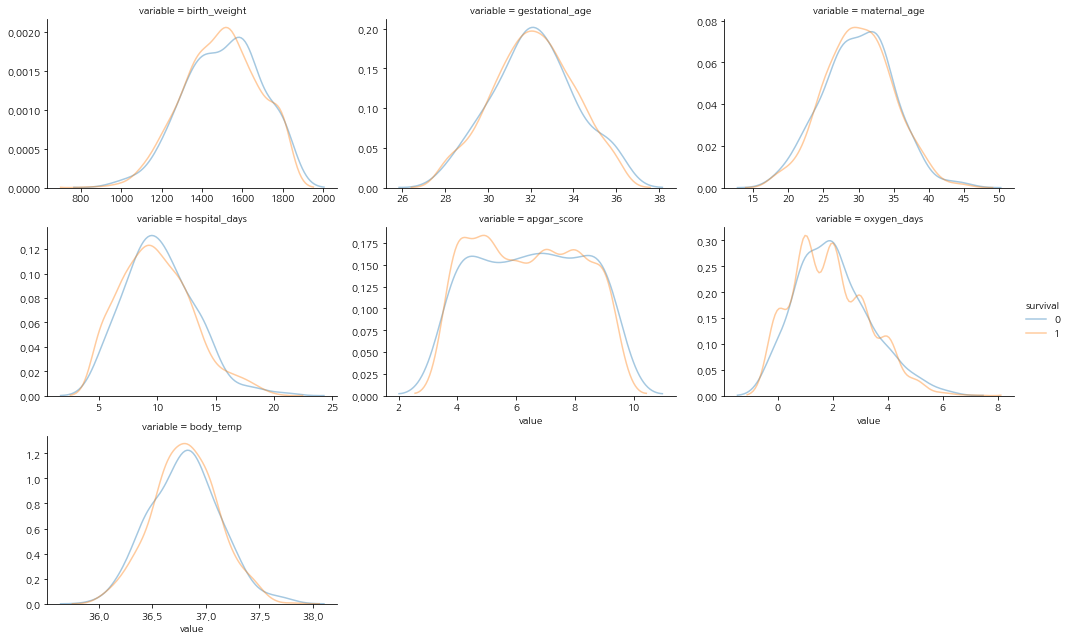

<< survival질적 변수 분포 시각화>>


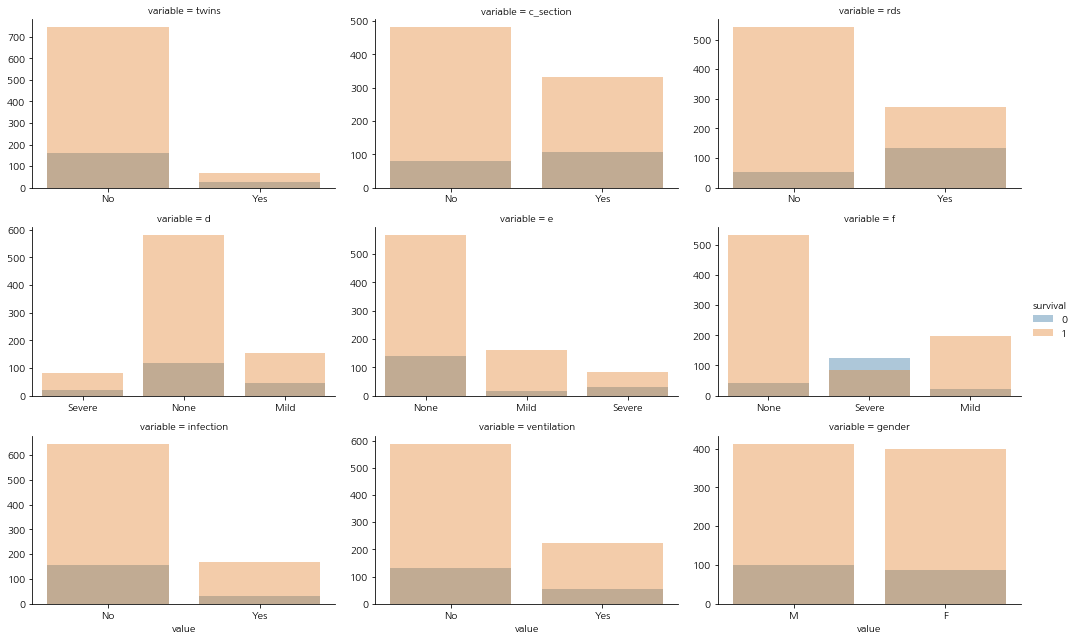

<<bd 연속형 변수 분포 시각화>>


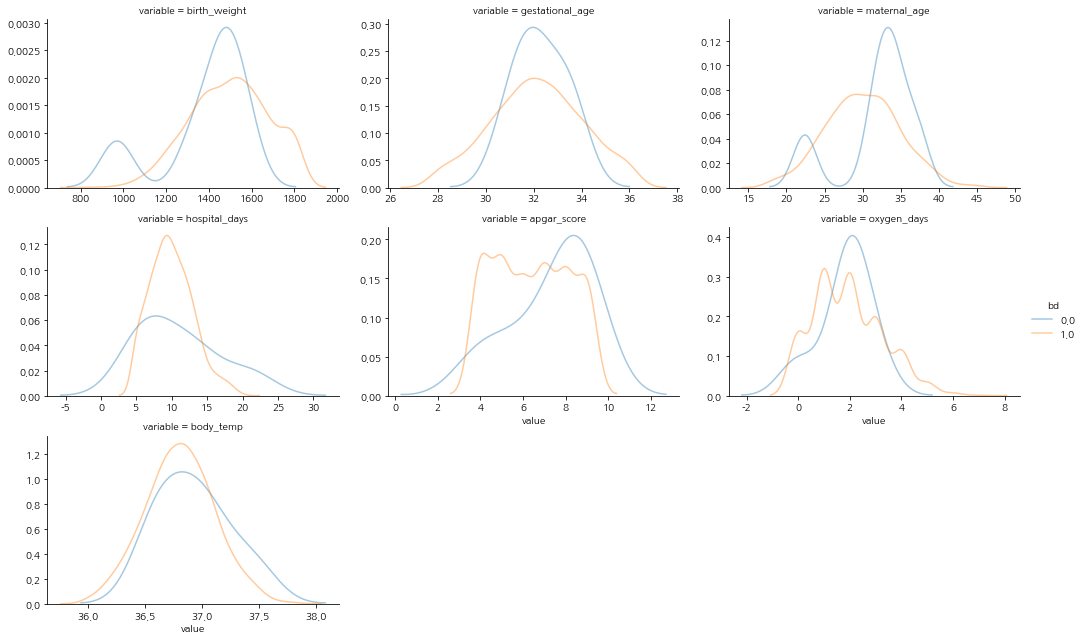

<< bd질적 변수 분포 시각화>>


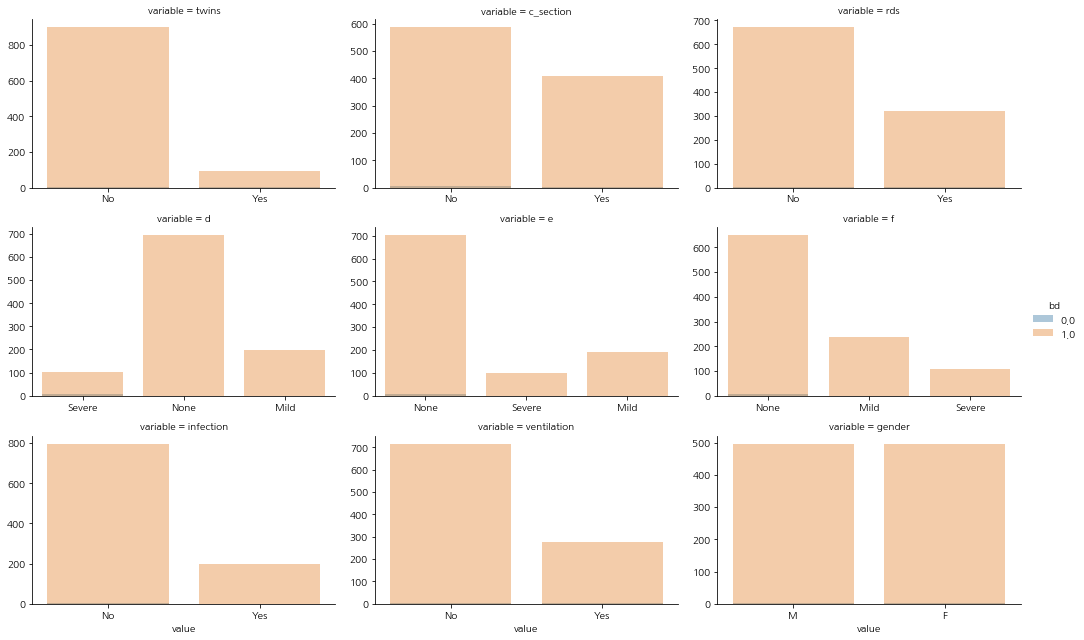

In [154]:
for o in ob:
    print(f"<<{o} 연속형 변수 분포 시각화>>")
    mt = df.melt(id_vars=o, value_vars=n_cols)
    g = sns.FacetGrid(mt, col='variable', hue=o, col_wrap=3, sharex=False, sharey=False, aspect=1.6)
    g.map(sns.kdeplot, 'value', alpha=0.4)
    g.add_legend()
    plt.show()
    print(f"<< {o}질적 변수 분포 시각화>>")
    mt = df.melt(id_vars=o, value_vars=c_cols)
    g = sns.FacetGrid(mt, col='variable', hue=o, col_wrap=3, sharex=False, sharey=False, aspect=1.6)
    g.map(sns.countplot, 'value', alpha=0.4)
    g.add_legend()
    plt.show()

생존여부 변수 비교  

생존여부 변수를 hue로 하여 분포시각화 비교 시 연속형 변수 간 분포의 차이는 유사하다.(이는 분포차이의 특징이 없음을 뜻함)  
단, 사망영아의 뇌손상 변수 f의 값이 큼을 알 수 있다.  

뇌손상 여부 변수 비교  
연속형 변수의 각 레이블 간 분포 차이가 확연하다.  
뇌손상이 있을 경우 몸무게는 음의 왜도로 정상 대비 비교적 크며(정상은 쌍봉분포)  
임신주수는 짧다(첨도가 높음)  
또한 어머니 나이의 분포도 정상은 쌍봉분포를 보이는 데 비해 30을 중심으로 정규분포 형태를 보인다.  

질적변수는 뇌손상 변수의 심한 불균형으로 비교가 쉽지 않음

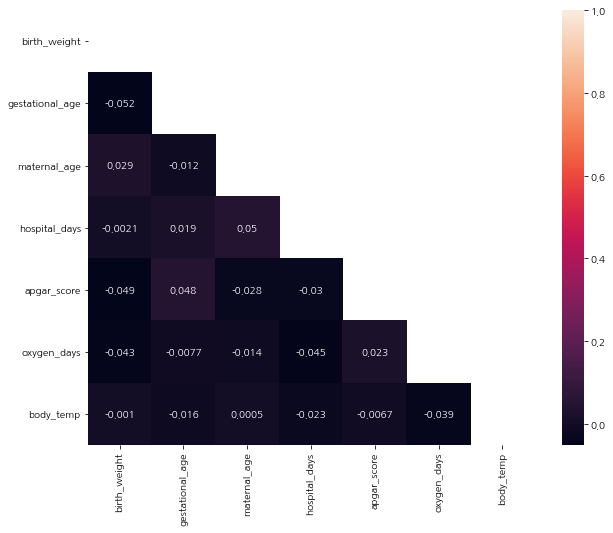

In [157]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

피어슨 선형관계 상 유의미한 선형 상관관계는 없다.  따라서 다중공선성은 관찰되지 않는다.

분류분석
- 로지스틱, 의사결정나무, 랜덤포레스트, xgboost

survaial 예측

In [188]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, average_precision_score, classification_report

x = df.drop('survival', axis=1)
y = df['survival'].astype('int64')

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)


n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

pre = make_column_transformer(
    (Pipeline([('scal', StandardScaler())]), n_cols), 
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

pre2 = make_column_transformer(
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

#단순모델
lr = Pipeline([
    ('pre', pre), 
    ('smote', SMOTE(random_state=42)), 
    ('cl', LogisticRegression(random_state=42))
])

dt = Pipeline([
    ('pre', pre2), 
    ('smote', SMOTE(random_state=42)), 
    ('cl', DecisionTreeClassifier(random_state=42))
])

#앙상블
rf = Pipeline([
    ('pre', pre2), 
    ('smote', SMOTE(random_state=42)),
    ('cl', RandomForestClassifier(random_state=42))
])
xgb = Pipeline([
    ('pre', pre2), 
    ('smote', SMOTE(random_state=42)), 
    ('cl', XGBClassifier(random_state=42))
])

rs = pd.DataFrame(columns=['model', 'data', 'acc', 'f1', 'pr_auc'])

m_list = [('로지스틱', lr), ('의사결정나무', dt), ('랜덤포레스트', rf), ('xgb', xgb)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

for n1, model in m_list:
    model.fit(train_x, train_y)
    for n2, x, y in d_list:
        pred = model.predict(x)
        acc = accuracy_score(y, pred)
        f1 = f1_score(y, pred, average='macro')
        pr = average_precision_score(y, pred, average='macro')
        cm = classification_report(y, pred)
        rs.loc[len(rs)] = [n1, n2, acc, f1, pr]
display(rs)


,model,data,acc,f1,pr_auc
0,로지스틱,train,0.578667,0.510432,0.834792
1,로지스틱,test,0.556000,0.477313,0.816327
2,의사결정나무,train,1.000000,1.000000,1.000000
3,의사결정나무,test,0.664000,0.475000,0.804240
4,랜덤포레스트,train,1.000000,1.000000,1.000000
5,랜덤포레스트,test,0.808000,0.446903,0.811249
6,xgb,train,0.858667,0.655432,0.851955
7,xgb,test,0.800000,0.463427,0.812240


In [176]:
pre.fit_transform(train_x).shape

(750, 32)

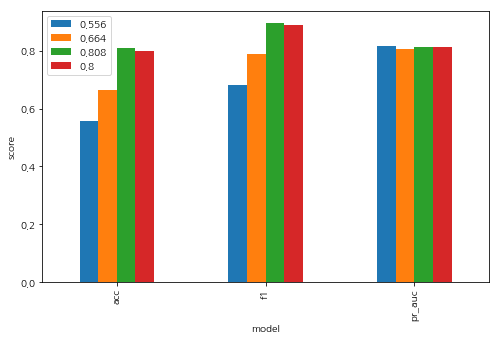

In [186]:
tmp = rs[rs['data'] == 'test'].drop(columns=['data', 'model']).T
tmp.columns = tmp.iloc[0].values
tmp.plot(kind='bar', figsize=(8, 5))
plt.xlabel('model')
plt.ylabel('score')
plt.legend()
plt.show()

4개 모델 성능 비교결과 전체적인 정확도 기준으로는 랜덤포레스트, xgboost 두 앙상블 모델이 높았으나  
해당 종속변수는 불균형 데이터였으므로 f1, pr_auc를 기준으로 평가한다.  

그 중 로지스틱 회귀 모델이 과적합 없이 f1, pr_auc 값이 0.47731/0.816327로 가장 높은 성능을 보여주었다.  

조화평균의 값이 상당히 낮다는 것은 특히 마이너리티 클래스였던 사망영아의 예측을 잘 해내지 못함(오분류)을 의미한다.


In [190]:
prd = lr.predict(test_x)

cm = classification_report(test_y, pred)
print(cm)

              precision    recall  f1-score   support

           0       0.20      0.02      0.04        47
           1       0.81      0.98      0.89       203

    accuracy                           0.80       250
   macro avg       0.51      0.50      0.46       250
weighted avg       0.70      0.80      0.73       250



레이블 0의 precision(사망영아로 예측한 데이터가 실제 사망영아일 경우) 가 불과 0.2밖에 되지 않고  
recall은 더 낮은 0.02로 실제 사망영아를 제대로 예측해내지 못함을 알 수 있다.   

smote 를 적용했지만 심각한 불균형을 해소하지는 못한다.  
따라서 추가적인 관찰데이터 수집 후 다시 분석을 수행하는 것이 고려된다.  

### 2. 머신러닝

#### [문제 2] 재생에너지 발전량 예측 (Energy.csv, Climate.csv)
#### 두 데이터셋은 2021~2023년 3년간의 재생에너지 발전량과 기후 데이터를 포함합니다.

- Energy.csv:
- 변수: date(YYYYMMDD), source(태양광/풍력), generation(MWh), hour_0~hour_23(시간별 발전량)
총 발전량(generation)은 태양광과 풍력의 합.
- Climate.csv:
- 변수: date(YYYY-MM-DD), temperature(기온), humidity(습도), windspeed(풍속), precipitation(강수량)
- 일부 변수(temperature, precipitation)에 결측값 존재.

#### 데이터 특이사항:

- Energy.csv: 약 1000일 데이터, 결측값 5% 이하.
- Climate.csv: 약 1100일 데이터, 결측값 10% 내외.
- Python(Pandas, sklearn) 또는 R(dplyr, caret)로 분석 가능.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

energy_df = pd.read_csv('Energy.csv')
climate_df = pd.read_csv('Climate.csv')
energy_df.drop(columns=['generation'], inplace=True, axis=1)
display(energy_df.head())
display(climate_df.head())

,date,source,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,20210101,Solar,10.612776,18.919571,16.477538,8.827337,11.027004,7.320036,10.068342,4.565273,...,13.887643,11.554141,6.316949,1.052565,11.417600,15.073001,10.228990,13.390003,2.489640,9.963013
1,20210101,Wind,7.421830,5.520150,13.688934,19.836831,13.963826,9.462576,4.057822,16.606856,...,7.451766,8.677991,10.594264,13.060985,13.648189,4.026717,7.523877,19.683184,10.749592,0.637982
2,20210102,Solar,16.843117,7.082532,17.834894,5.903762,7.068822,7.476683,1.746394,4.873352,...,12.921522,11.551500,21.283893,6.781420,12.665406,12.035176,11.307375,17.278912,6.939721,2.568380
3,20210102,Wind,6.527484,4.081912,25.683430,15.869641,10.594932,23.009171,5.265074,3.742647,...,12.606121,6.423788,17.117713,7.361706,1.396033,12.943102,8.819983,10.153434,14.098082,14.236364
4,20210103,Solar,11.144246,13.060810,17.157265,17.923698,9.272692,12.561377,12.055105,9.167380,...,9.896769,8.531589,12.683250,11.809802,9.818225,2.075185,17.261561,12.466698,16.477671,15.787612


,date,temperature,humidity,windspeed,precipitation
0,2021-01-01,8.196357,60.767346,7.229558,0.133543
1,2021-01-02,7.842254,71.605808,1.878436,3.203037
2,2021-01-03,8.548918,46.904014,4.651294,2.122495
3,2021-01-04,25.446324,87.003296,0.126070,2.307601
4,2021-01-05,14.434452,52.582675,3.209874,0.562203


#### 2. 결측값 처리:
- temperature, precipitation은 결측값을 0으로 대체.
- 그 외 변수(humidity, windspeed 등)는 직전 값(Forward Fill)으로 대체.

In [70]:
c1 = ['temperature', 'precipitation']
climate_df[c1] = climate_df[c1].fillna(0)

c2 = ['humidity', 'windspeed']
climate_df[c2] = climate_df[c2].fillna(method='ffill')

climate_df.isna().sum()

date             0
temperature      0
humidity         0
windspeed        0
precipitation    0
dtype: int64

In [73]:
#발전량 집계
c3 = energy_df.columns[2:]
energy_df = energy_df.groupby('date')[c3].sum().reset_index()
energy_df.isna().sum()

date       0
hour_0     0
hour_1     0
hour_2     0
hour_3     0
hour_4     0
hour_5     0
hour_6     0
hour_7     0
hour_8     0
hour_9     0
hour_10    0
hour_11    0
hour_12    0
hour_13    0
hour_14    0
hour_15    0
hour_16    0
hour_17    0
hour_18    0
hour_19    0
hour_20    0
hour_21    0
hour_22    0
hour_23    0
dtype: int64

In [74]:
# 둘 병합
mt = energy_df.melt(id_vars='date', var_name='time', value_name='발전량')
mt['time'] = mt['time'].str.replace('hour_', '').astype('int64')

mt.head()


,date,time,발전량
0,20210101,0,18.034606
1,20210102,0,23.370601
2,20210103,0,27.904033
3,20210104,0,19.964425
4,20210105,0,22.405221


In [79]:
mt['date'] = pd.to_datetime(mt['date'], format='%Y%m%d').dt.strftime('%Y-%m-%d')
mt.head()

,date,time,발전량
0,2021-01-01,0,18.034606
1,2021-01-02,0,23.370601
2,2021-01-03,0,27.904033
3,2021-01-04,0,19.964425
4,2021-01-05,0,22.405221


In [80]:
d2 = pd.merge(climate_df, mt, on='date', sort='date')

d2.head()

,date,temperature,humidity,windspeed,precipitation,time,발전량
0,2021-01-01,8.196357,60.767346,7.229558,0.133543,0,18.034606
1,2021-01-01,8.196357,60.767346,7.229558,0.133543,1,24.439721
2,2021-01-01,8.196357,60.767346,7.229558,0.133543,2,30.166472
3,2021-01-01,8.196357,60.767346,7.229558,0.133543,3,28.664168
4,2021-01-01,8.196357,60.767346,7.229558,0.133543,4,24.990830


In [82]:
len(d2)

26280

In [83]:
d2.isna().sum()

date             0
temperature      0
humidity         0
windspeed        0
precipitation    0
time             0
발전량              0
dtype: int64

#### 3. 파생변수 생성:
- Season: 월을 기준으로 계절 변수 생성 (3-5월: 봄, 6-8월: 여름, 9-11월: 가을, 12-2월: 겨울).

In [84]:
d2['date'] = pd.to_datetime(d2['date'])

d2['mon'] = d2['date'].dt.month

cond1 = d2['mon'].between(3, 5)
cond2 = d2['mon'].between(6, 8)
cond3 = d2['mon'].between(9, 11)

d2['season'] = np.where(cond1, '봄', 
                       np.where(cond2, '여름', 
                               np.where(cond3, '가을', '겨울')))

d2['season'].value_counts()

여름    6624
봄     6624
가을    6552
겨울    6480
Name: season, dtype: int64

#### 4. 탐색적 분석:
- 변수 간 상관관계 분석(예: generation과 temperature, windspeed 간 상관계수).
- 계절별 발전량 분포 시각화.

In [86]:
d2.drop('mon', axis=1, inplace=True)

In [93]:
c_cols = d2.select_dtypes('O').columns
n_cols = d2.select_dtypes('number').columns


#변수 간 상관관계 분석
from scipy.stats import pearsonr

for n in n_cols[:-1]:
    s, p = pearsonr(d2['발전량'], d2[n])
    print(f"발전량-{n} 피어슨 상관계수: {s:.3f} / pvalue: {p:.3f}", "(유의)" if p < 0.05 else "")

발전량-temperature 피어슨 상관계수: 0.010 / pvalue: 0.117 
발전량-humidity 피어슨 상관계수: 0.001 / pvalue: 0.851 
발전량-windspeed 피어슨 상관계수: 0.018 / pvalue: 0.004 (유의)
발전량-precipitation 피어슨 상관계수: -0.018 / pvalue: 0.004 (유의)
발전량-time 피어슨 상관계수: 0.008 / pvalue: 0.199 


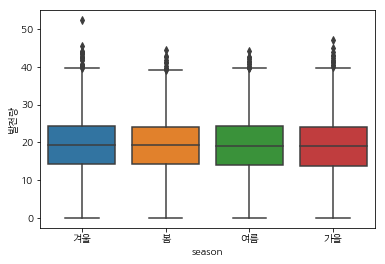

In [99]:
sns.boxplot(data=d2, y='발전량', x='season')
plt.show()

각 계절별 발전량의 분포는 비슷함.  단 겨울에 50 상단에서 큰 이상치 값을 보임

#### 5. 데이터 분할 및 예측:
- 2021~2022년 데이터를 학습(train), 2023년 데이터를 테스트(test)로 분할.
- 선형회귀, 랜덤포레스트를 사용하여 총 발전량(generation) 예측.
- 성능 평가: RMSE, R².

In [102]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17520 entries, 0 to 17519
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           17520 non-null  datetime64[ns]
 1   temperature    17520 non-null  float64       
 2   humidity       17520 non-null  float64       
 3   windspeed      17520 non-null  float64       
 4   precipitation  17520 non-null  float64       
 5   time           17520 non-null  int64         
 6   발전량            17520 non-null  float64       
 7   season         17520 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 1.2+ MB


In [103]:
d2['time'] = d2['time'].astype('O')

In [104]:
train, test = d2[d2['date'].dt.year.isin(['2021', '2022'])], d2[d2['date'].dt.year.isin(['2023'])]

print(train.shape, test.shape)

(17520, 8) (8760, 8)


In [106]:
train_x, train_y = train.drop(columns=['date', '발전량']), train['발전량']
test_x, test_y = test.drop(columns=['date', '발전량']), test['발전량']

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

pre = make_column_transformer(
    (Pipeline([('sr', StandardScaler())]), n_cols), 
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

pre2 = make_column_transformer(
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

lr = Pipeline([
    ('pre', pre), 
    ('rg', LinearRegression())
])

rf = Pipeline([
    ('pre', pre2), 
    ('rg', RandomForestRegressor(random_state=42))
])

m_l = [('선형회귀', lr), ('랜덤포레스트', rf)]
d_l = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'r2', 'rmse'])

for n1, model in m_l:
    model.fit(train_x, train_y)
    for n2, x, y in d_l:
        pred = model.predict(x)
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [n1, n2, r2, rmse]
display(rs)

,model,data,r2,rmse
0,선형회귀,train,0.004771,7.497419
1,선형회귀,test,-0.008584,7.363429
2,랜덤포레스트,train,0.879950,2.603943
3,랜덤포레스트,test,-0.078255,7.613507


In [108]:
7.363429/(test_y.max() - test_y.min())

0.1562313815091767

모델 학습결과 해석

두 지표로 평가결과, 선형회귀 모델의 성능이 높다.  
랜덤포레스트의 학습데이터는 성능이 높지만, 테스트셋에서는 아주 낮은 성능을 보여 과적합 현상을 보인다.  

선형회귀의 test set 학습결과는 r2 score: -0.008584	rmse: 7.363429로 r2 계수값이 음수이므로 종속변수의 변동을 잘 설명하지 못하며  
단순히 평균을 예측하는 모델보다 성능이 떨어짐을 알 수 있다.  

rmse는 test set 종속변수 범위 간 약 15.6%의 표준오차를 보인다고 할 수 있다.  

따라서 성능이 나쁘며, 랜덤포레스트의 과적합 현상을 보았을 때, train/test set 간 분포가 확연히 다르다는 것을 추측할 수 있다.  
따라서 train/test set의 분포를 균일하게 한 후 다시 모델 적합하는 것을 고려한다.

### 3. 통계분석

#### [문제 3] 분산분석: 학습방법과 성별에 따른 성적 분석
#### 데이터셋은 학생 40명(남 20, 여 20)의 학습방법(3가지)별 성적을 포함합니다.
##### 변수:
- ID: 학생 식별자
- Gender: 성별 (M/F)
- LearningMethod: 학습방법 (Traditional, Online, Blended)
- Score: 성적 (0~100점)
##### 데이터 특이사항:
- 성적 분포: 평균 75, 표준편차 10 내외.
- Python(statsmodels) 또는 R(aov, TukeyHSD) 사용 권장.

In [4]:
d3 = pd.read_csv('./Learning_Score.csv')

In [5]:
d3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           40 non-null     int64 
 1   Gender       40 non-null     object
 2   Traditional  40 non-null     int64 
 3   Online       40 non-null     int64 
 4   Blended      40 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.7+ KB


In [6]:
d3.head()

,id,Gender,Traditional,Online,Blended
0,1,M,89,65,58
1,2,M,73,82,76
2,3,M,80,82,74
3,4,M,83,50,93
4,5,M,78,56,86


In [8]:
d3['Gender'].value_counts()

M    20
F    20
Name: Gender, dtype: int64

#### 1. 가정 검토:

Gender, 학습방법 모두 질적변수(명목형)이며, 두 변인에 따른 연속형 변수인 성적의 차이가 있는지 검정하는 것이므로  

분산분석 문제이다.  

단 성별은 beween 요인이고, 학습방법은 within 요인이므로 혼합설계 anova를 수행한다.  

단. 해당 모델은 다음의 가정을 만족해야 하므로 잔차를 통해 검정을 수행한다.  
단, 모델 적합 전 사전탐색 단계이므로 데이터를 통해 검정을 수행한다.  

- 정규성: 각 그룹은 정규분포를 따름
- 등분산성: between 그룹 간 잔차는 등분산성을 따름
- 구형성: within 요인 수준 간 공분산 행렬이 동일
- 독립성: 독립요인(between) 관찰값은 서로 독립 => 여기서는 수집된 데이터로 독립성을 만족한다고 판단

In [9]:
mt = d3.melt(id_vars=['id', 'Gender'], var_name='method', value_name='score')

In [16]:
from scipy.stats import shapiro, levene

g = [(name, g['score']) for name, g in mt.groupby(['Gender', 'method'])]

for name, g in g:
    s, p = shapiro(g)
    print(f"{name} 그룹 정규성 검정결과: 통계량 {s:.3f} / pvalue: {p:.3f} => 정규성 ", "만족" if p >= 0.05 else "불만족")
    
g = [g['score'] for name, g in mt.groupby(['Gender'])]
s, p = levene(*g)
print(f"등분산성 검정결과: 통계량 {s:.3f} / pvalue: {p:.3f} =>등분산성", "만족" if p >= 0.05 else "불만족")

('F', 'Blended') 그룹 정규성 검정결과: 통계량 0.948 / pvalue: 0.339 => 정규성  만족
('F', 'Online') 그룹 정규성 검정결과: 통계량 0.919 / pvalue: 0.094 => 정규성  만족
('F', 'Traditional') 그룹 정규성 검정결과: 통계량 0.956 / pvalue: 0.476 => 정규성  만족
('M', 'Blended') 그룹 정규성 검정결과: 통계량 0.961 / pvalue: 0.566 => 정규성  만족
('M', 'Online') 그룹 정규성 검정결과: 통계량 0.923 / pvalue: 0.115 => 정규성  만족
('M', 'Traditional') 그룹 정규성 검정결과: 통계량 0.977 / pvalue: 0.886 => 정규성  만족
등분산성 검정결과: 통계량 0.223 / pvalue: 0.638 =>등분산성 만족


정규성, 등분산성, 독립성은 만족한다.  다음으로 모델 적합 후 within 요인의 구형성을 확인한다.  

In [11]:
import pingouin as pg

model = pg.mixed_anova(dv='score', within='method', between='Gender', subject='id', data=mt, correction=True)

display(model)


,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,Gender,0.033333,1,38,0.033333,0.000260,9.872168e-01,NaN,0.000007,NaN,NaN,NaN,NaN
1,method,4539.216667,2,76,2269.608333,22.577354,2.013656e-08,1.676235e-08,0.372703,0.995929,True,0.995913,0.925132
2,Interaction,118.816667,2,76,59.408333,0.590976,5.563113e-01,NaN,0.015314,NaN,NaN,NaN,NaN


method의 GG eps가 0.995929로 1에 가까우므로 구형성을 만족한다.  

#### 2. 분산분석:
- 성별(Gender)과 학습방법(LearningMethod)의 주효과 및 상호작용 효과 분석 (mixed ANOVA, 만약 between간 유의하지 않으면 반복측정).

위에서 혼합설계 모형 적합결과를 해석하면, between 요인인 Gender의 pvalue가 9.872168e-01이므로 통계적으로 유의하지 않다.  
따라서 between 요인을 제외하고 반복측정 요인만을 사용한 일원 반복측정 분산분석을 수행한다.  

유의수준 5% 하에서 검정을 수행한다.  

- 귀무가설: 학습방법에 따른 성적차이가 없다. 
- 대립가설: 학습방법에 따른 성적차이가 있다. 

In [17]:
model = pg.rm_anova(dv='score', within='method', subject='id', data=mt)
display(model)

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,method,2,78,22.816651,1.579088e-08,0.369102,0.995929


GG eps 0.995929로 구형성 만족, pvalue 1.579088e-08로 귀무가설을 기각한다.   
따라서 학습방법 간 차이가 통계적으로 유의하다.  

#### 3. 사후분석:
- 유의미한 효과가 발견될 경우, Tukey HSD 테스트로 사후분석 수행.

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
Blended      Online  -14.525    0.0 -20.0399 -9.0101   True
Blended Traditional     -3.8 0.2348  -9.3149  1.7149  False
 Online Traditional   10.725    0.0   5.2101 16.2399   True
-----------------------------------------------------------


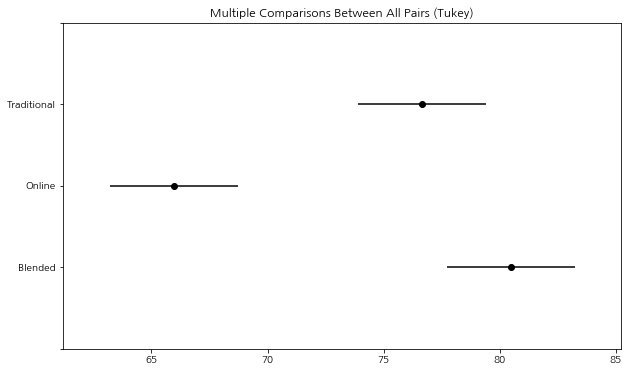

In [22]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=mt['score'], groups=mt['method'], alpha=0.05)

print(rs)

rs.plot_simultaneous()
plt.show()

#### 4. 결과 해석:
- 각 효과의 p-value와 통계적 유의성 논의.
- 학습방법별 평균 성적 비교 시각화.

Tukey HSD 검정결과 유의수준 5% 하에서 학습방법 (Blended - Traditional)를 제외한 모든 수준 간   
통계적으로 유의한 차이가 있다. (p-adj 확인)
(Blended - Traditional) 는 pvalue 0.2348로 0.05보다 커서 귀무가설을 기각할 수 없다.  

도표를 보면 중앙값 기준으로 블랜디드의 성적이 가장 높고, 전통적, 온라인 순이다.  

블랜디드와 전통적 방식은 통계적으로 차이가 유의하지는 않지만, 중앙값 기준으로 크기 때문에  비용과 기타요인을 따져  
큰 차이가 없다면 블랜디드 방식이 적합할 것이다.

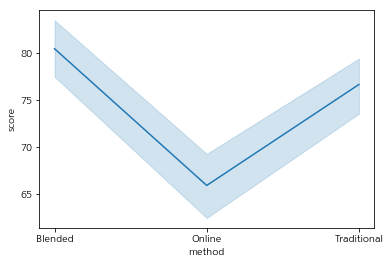

In [24]:
sns.lineplot(x=mt['method'], y=mt['score'])
plt.show()

### 4. 통계분석

#### [문제 4] 회귀분석: 학업 성취도 예측

#### 데이터셋은 학생 500명의 학업 관련 변수를 포함하며, 국어 성적을 예측하는 회귀분석을 수행합니다.

- 변수:
- ID: 학생 식별자
- StudyTime: 주간 공부시간 (0: 10시간 이하, 1: 1115시간, 2: 1620시간, 3: 21~25시간, 4: 26시간 이상)
- Tutoring: 과외 여부 (Yes/No)
- OnlineCourse: 온라인 강의 수강 여부 (Yes/No)
- Absences: 결석 일수 (평균 4, Q3: 8, 최대 25)
- Failures: 낙제 횟수 (0~3)
- Score: 국어 성적 (0~20점)
#### 데이터 특이사항:
- 결측값: 약 5% (Absences, Failures 중심).
- 범주형 변수(Tutoring, OnlineCourse)는 더미 변수로 변환 필요.
- Python(sklearn, statsmodels) 또는 R(lm, randomForest) 사용 권장.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

d4 = pd.read_csv('Academic_Performance.csv')

In [27]:
d4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            500 non-null    int64  
 1   StudyTime     500 non-null    int64  
 2   Tutoring      500 non-null    object 
 3   OnlineCourse  500 non-null    object 
 4   Absences      475 non-null    float64
 5   Failures      475 non-null    float64
 6   Score         500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


In [32]:
d4['StudyTime'] = d4['StudyTime'].astype('O')

In [28]:
d4.head()

,id,StudyTime,Tutoring,OnlineCourse,Absences,Failures,Score
0,1,3,Yes,Yes,8.0,0.0,12
1,2,1,Yes,Yes,4.0,2.0,11
2,3,1,Yes,No,7.0,1.0,14
3,4,2,No,No,7.0,1.0,14
4,5,0,No,Yes,5.0,1.0,11


In [30]:
d4.isna().mean()*100

id              0.0
StudyTime       0.0
Tutoring        0.0
OnlineCourse    0.0
Absences        5.0
Failures        5.0
Score           0.0
dtype: float64

결석컬럼과 Failures 컬럼에서 결측치가 보인다.  약 5% 정도로 크지 않으며, 원 데이터의 데이터 왜곡을 피하기 위해  
삭제한다. 

In [31]:
d4 = d4.dropna()

#### 가정 검토:

다음의 전제조건을 만족해야 회귀계수의 신뢰성이 보장된다.   

모델적합 후 잔차를 통해 검정을 수행한다.  

- 선형성: 예측값과 잔차간 패턴 없으며 무작위 분포
- 정규성: 잔차는 정규분포를 따름
- 등분산성: 잔차의 분산의 균일함
- 독립성: 잔차 간 서로 독립
- 다중공선성 없음: vif가 10이상이지 않을 것

In [38]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


y = d4['Score']
x = d4.drop(columns=['Score', 'id'])

x = pd.get_dummies(x, columns=x.select_dtypes('O').columns, drop_first=True)

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)


lr = sm.OLS(train_y, sm.add_constant(train_x)).fit()

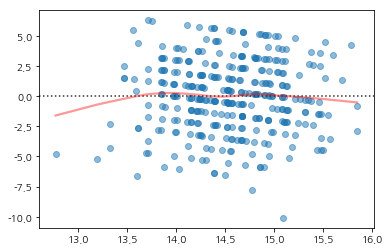

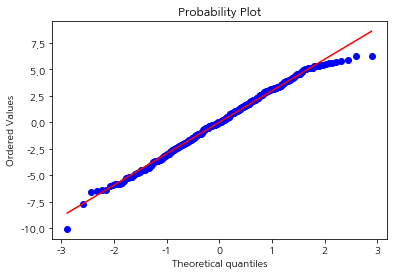

잔차 정규성 검정결과 통계량: 0.992 / pvalue: 0.065
잔차 등분산 검정결과 통계량: 7.913 / pvalue: 0.442
더빈왓슨 독립성 검정결과: 1.901287301373148


In [42]:
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import probplot
from statsmodels.stats.stattools import durbin_watson

fitted = lr.fittedvalues
resid = lr.resid

sns.residplot(x=fitted, y=resid, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'alpha': 0.4, 'color': 'r'})
plt.show()

probplot(resid, fit=True, dist='norm', plot=plt)
plt.show()

s, p = shapiro(resid)
print(f"잔차 정규성 검정결과 통계량: {s:.3f} / pvalue: {p:.3f}")

s, p, _, _ = het_breuschpagan(resid, lr.model.exog)
print(f"잔차 등분산 검정결과 통계량: {s:.3f} / pvalue: {p:.3f}")

print(f"더빈왓슨 독립성 검정결과: {durbin_watson(resid)}")


- 독림성: 잔차가 패턴을 보이지 않으며 균등 분포하므로 만족
- 등분산성: 잔차-예측값 산점도 상 회귀선이 대체로 직선이며, 등분산 검정결과 pvalue가 0.05 이상이므로 만족
- 정규성: 만족(shapiro pvalue 0.065이므로 귀무가설 기각 불가)
- 독립성: 만족(dw 값이 1.5-2.5 사이)
- 다중공선성은 아래에서 검정한다.

#### 회귀분석:
선형회귀분석 수행(종속변수: Score, 독립변수: StudyTime, Tutoring, OnlineCourse, Absences, Failures).
기계학습 모델(예: 랜덤포레스트)과 비교.

In [43]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.309
Date:                Sat, 11 Oct 2025   Prob (F-statistic):              0.238
Time:                        16:51:33   Log-Likelihood:                -892.19
No. Observations:                 356   AIC:                             1802.
Df Residuals:                     347   BIC:                             1837.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               14.6883      0.524  

- 귀무가설: 모델의 회귀계수는 0이다.
- 대립가설: 적어도 하나의 회귀계수는 0이 아니다.

(유의수준 5% 하)

다중선형회귀 F 통계량 pvalue가 0.238으로 귀무가설을 기각할 수 없으므로 통계적 유의성이 있는 모델이 아님
또한 모든 회귀계수의 T통계량 pvalue가 귀무가설을 기각할 수 없으므로 유의하지 않음


In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(random_state=42)
rf.fit(train_x, train_y)
m_list = [('다중회귀', lr), ('랜덤포레스트', rf)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'r2', 'rmse'])

for n1, model in m_list:
    for n2, x, y in d_list:
        if n1 == '다중회귀':
            pred = np.where(model.predict(sm.add_constant(x))>=0.5, 1, 0)
        else:
            pred = model.predict(x)
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [n1, n2, r2, rmse]
display(rs)

,model,data,r2,rmse
0,다중회귀,train,-20.244275,13.875449
1,다중회귀,test,-27.522544,14.175076
2,랜덤포레스트,train,0.549281,2.021060
3,랜덤포레스트,test,-0.474444,3.222889


두 모델의 학습결과를 보았을 때도 랜덤포레스트의 학습결과가 확연히 좋았다.  

따라서 다중회귀 모델이 통계적으로 유의하지 않기 때문에 회귀계수를 신뢰할 수 없으며 예측성능이 나쁘다는 것을 알 수 있다.  

랜덤포레스트는 과적합이 없으며 성능 또한 우수하다.  
단 랜덤포레스트는 비선형 특징까지 학습할 수 있으며, r2 score 는 ssr/sst로 모델변동의 선형적인 설명력을 나타내기 때문에  
단순히 음수가 나왔다고 해서 성능이 나쁘지는 않다.

#### 다중공선성:
VIF(Variance Inflation Factor) 계산 및 다중공선성 평가.

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
n = lr.model.exog_names
vif['name'] = n
vif['vif'] = [variance_inflation_factor(lr.model.exog, i) for i in range(len(n))]

display(vif[1:])

,name,vif
1,Absences,1.036553
2,Failures,1.019823
3,StudyTime_1,1.653966
4,StudyTime_2,1.717767
5,StudyTime_3,1.397598
6,StudyTime_4,1.303099
7,Tutoring_Yes,1.021990
8,OnlineCourse_Yes,1.024629


vif 검정결과 모든 독립변수의 회귀계수가 1에 가까우며, 10 이상이 없으므로 다중공선성이 없다. 

#### 변수 중요도:
회귀계수의 p-value를 통해 통계적 유의성 확인.
랜덤포레스트의 feature importance 분석.

In [57]:
print(lr.pvalues<0.05)

const                True
Absences            False
Failures            False
StudyTime_1         False
StudyTime_2         False
StudyTime_3         False
StudyTime_4         False
Tutoring_Yes        False
OnlineCourse_Yes    False
dtype: bool


모든 회귀계수가 통계적으로 유의하지 않다. 다음으로 랜덤포레스트의 변수중요도를 시각화한다.

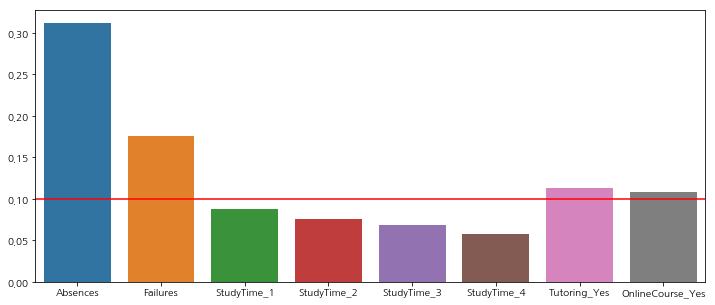

In [62]:
n = train_x.columns
fm = rf.feature_importances_


plt.figure(figsize=(12, 5))
sns.barplot(x=n, y=fm)
plt.axhline(y=0.1, color='r')
plt.show()

10% 이상의 중요도를 순서대로 나열한다.  
Absences, Falures, 튜토링, 온라인 코스 순으로 모델 학습에 중요한 영향을 끼침을 알 수 있다. 

#### 모델 평가:
R²: 모델이 성적의 변동을 얼마나 설명하는지 해석.
RMSE: 예측 오차 평가.

In [68]:

(test_y.max() - test_y.min())

12

다중선형 회귀 모델 기준으로 모델을 평가한다.  

R2 score는 -27.522544로 높은 음수값이며, 이는 종속변수의 변동을 잘 설명하지 못함을 뜻하며 단순하게 평균을 예측하는 모델보다  
성능이 낮다는 것을 뜻한다.  

rmse 14.175076는 종속변수의 범위가 12인데 무려 범위 이상의 표준오차가 있음을 뜻한다.  

아주 낮은 성능으로 모델활용성이 없다.

In [209]:
import numpy as np
from itertools import combinations
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# 예시 데이터: 반복 측정 3개 조건 A, B, C
data = {
    'A': np.random.normal(loc=75, scale=5, size=30),  # 조건 A 성적
    'B': np.random.normal(loc=78, scale=5, size=30),  # 조건 B 성적
    'C': np.random.normal(loc=80, scale=5, size=30)   # 조건 C 성적
}

# 모든 조건 쌍에 대해 대응표본 t-검정 수행
pairs = list(combinations(data.keys(), 2))
p_values = []
for i, j in pairs:
    s, p = ttest_rel(data[i], data[j])
    p_values.append(p)

# Bonferroni 교정
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# 결과 출력
for (i, j), p_raw, p_corr, rej in zip(pairs, p_values, p_adjusted, reject):
    print(f"{i} vs {j}: raw p={p_raw:.3f}, bonf p={p_corr:.3f}, significant={rej}")


A vs B: raw p=0.020, bonf p=0.059, significant=False
A vs C: raw p=0.000, bonf p=0.000, significant=True
B vs C: raw p=0.006, bonf p=0.017, significant=True


In [210]:
import statsmodels.api as sm

# mtcars 데이터 불러오기
mtcars = sm.datasets.get_rdataset("mtcars", package="datasets").data

mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [220]:
import statsmodels.formula.api as smf

In [229]:

model_M = smf.ols("wt ~ disp*am", data=mtcars).fit()
model_Y = smf.ols("mpg ~ disp*am + wt*am", data=mtcars).fit()

print(model_M.summary())
print(model_Y.summary())

                            OLS Regression Results                            
Dep. Variable:                     wt   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     46.11
Date:                Sat, 11 Oct 2025   Prob (F-statistic):           5.84e-11
Time:                        22:59:53   Log-Likelihood:                -15.693
No. Observations:                  32   AIC:                             39.39
Df Residuals:                      28   BIC:                             45.25
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.0907      0.280      7.474      0.0

In [11]:
from scipy.stats import gamma

print("낚시를 하는데 어부가 물고기를 30분에 한 마리씩 잡는다. \n어부가 4마리의 물고기를 잡을 때까지 걸리는 시간이 1시간에서 3시간 사이로 소요될 확률은?")

lam = 2 # 시간으로 환산 시 2마리임
beta = 1/lam
a = 4 # 몇번의 사건
E = a*beta
V = a*(beta**2)
cdf = gamma.cdf(3, a, scale=beta) - gamma.cdf(1, a, scale=beta)

print(f"\n기댓값: {E}, 분산: {V}, 누적확률: {cdf:.3f}")

낚시를 하는데 어부가 물고기를 30분에 한 마리씩 잡는다. 
어부가 4마리의 물고기를 잡을 때까지 걸리는 시간이 1시간에서 3시간 사이로 소요될 확률은?

기댓값: 2.0, 분산: 1.0, 누적확률: 0.706


In [32]:
e, v = gamma.stats(20, scale=1/1.6, moments='mv')

gamma.cdf(15, 20, scale=1/1.6)

0.8197394858298082

In [33]:
e, v

(array(12.5), array(7.8125))

In [34]:
gamma.cdf(0, 20, scale=1/1.6)

0.0